# Power plant analysis

Base: [Source](https://github.com/pypsa-meets-earth/documentation/blob/main/notebooks/network_analysis.ipynb)

Adapted: Alexander Meisinger, OTH Regensburg

In [74]:
import yaml
import pypsa
import warnings
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np
import pandas as pd
from pathlib import Path
import seaborn as sns
from datetime import datetime
from cartopy import crs as ccrs
from pypsa.plot import add_legend_circles, add_legend_lines, add_legend_patches
import os
import xarray as xr
import cartopy
import warnings

### Own country analysis

In [75]:
country = "Bulgaria"
run_name = "1h-sec"

# Network file
results_path = f"/mnt/e/HySEE/{country}/pypsa-earth/results/{run_name}/postnetworks/elec_s_10_ec_lcopt_Co2L0.45-1h_1h_2030_0.07_AB_0export.nc"
network_path = f"/mnt/e/HySEE/{country}/pypsa-earth/networks/{run_name}/elec.nc"

# Country shape file
regions_onshore_path = f"/mnt/e/HySEE/{country}/pypsa-earth/resources/{run_name}/shapes/country_shapes.geojson"
# Renewable profile file
solar_path = f"/mnt/e/HySEE/{country}/pypsa-earth/resources/{run_name}/renewable_profiles/profile_solar.nc"
onwind_path = f"/mnt/e/HySEE/{country}/pypsa-earth/resources/{run_name}/renewable_profiles/profile_onwind.nc"

### Energy system analysis setup - power and energy generation

In [76]:
warnings.simplefilter(action='ignore', category=FutureWarning)
n = pypsa.Network(results_path)
regions_onshore = gpd.read_file(regions_onshore_path)
country_coordinates = regions_onshore.total_bounds[[0, 2, 1, 3]]
warnings.simplefilter(action='default', category=FutureWarning)

INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_Co2L0.45-1h_1h_2030_0.07_AB_0export.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


### Data import check: Country check

Text(0.5, 1.0, 'BG')

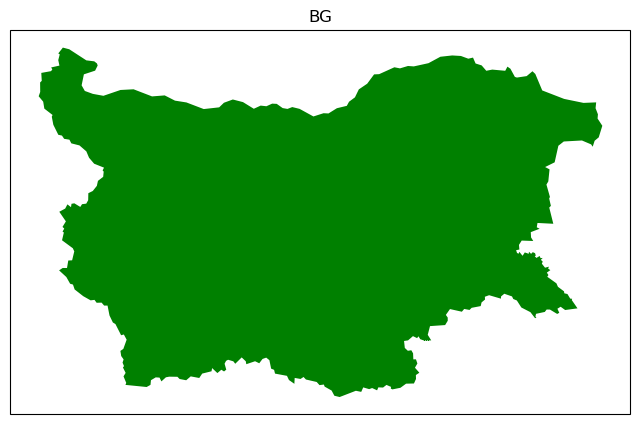

In [77]:
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": ccrs.EqualEarth()})
with plt.rc_context({"patch.linewidth": 0.}):
    regions_onshore.plot(
    ax=ax,
    facecolor="green",
    edgecolor="white",
    aspect="equal",
    transform=ccrs.PlateCarree(),
    linewidth=0,
    )
ax.set_title(", ".join(regions_onshore.name.values))

Component check

In [78]:
for c in n.iterate_components(list(n.components.keys())[2:]):
    print("Component '{}' has {} entries".format(c.name,len(c.df)))

Component 'Bus' has 256 entries
Component 'Carrier' has 46 entries
Component 'GlobalConstraint' has 1 entries
Component 'Line' has 56 entries
Component 'LineType' has 35 entries
Component 'TransformerType' has 14 entries
Component 'Link' has 586 entries
Component 'Load' has 28 entries
Component 'Generator' has 463 entries
Component 'StorageUnit' has 7 entries
Component 'Store' has 200 entries


Snapshot check

In [79]:
print(n.snapshots)
print(f"Time steps: " + str(len(n.snapshots)))

DatetimeIndex(['2013-01-01 00:00:00', '2013-01-01 01:00:00',
               '2013-01-01 02:00:00', '2013-01-01 03:00:00',
               '2013-01-01 04:00:00', '2013-01-01 05:00:00',
               '2013-01-01 06:00:00', '2013-01-01 07:00:00',
               '2013-01-01 08:00:00', '2013-01-01 09:00:00',
               ...
               '2013-12-31 14:00:00', '2013-12-31 15:00:00',
               '2013-12-31 16:00:00', '2013-12-31 17:00:00',
               '2013-12-31 18:00:00', '2013-12-31 19:00:00',
               '2013-12-31 20:00:00', '2013-12-31 21:00:00',
               '2013-12-31 22:00:00', '2013-12-31 23:00:00'],
              dtype='datetime64[ns]', name='snapshot', length=8760, freq=None)
Time steps: 8760


### Analyse the current capacity of the energy system - map view

/home/alex-charly/anaconda3/envs/pypsa-earth-HySEE-BG/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


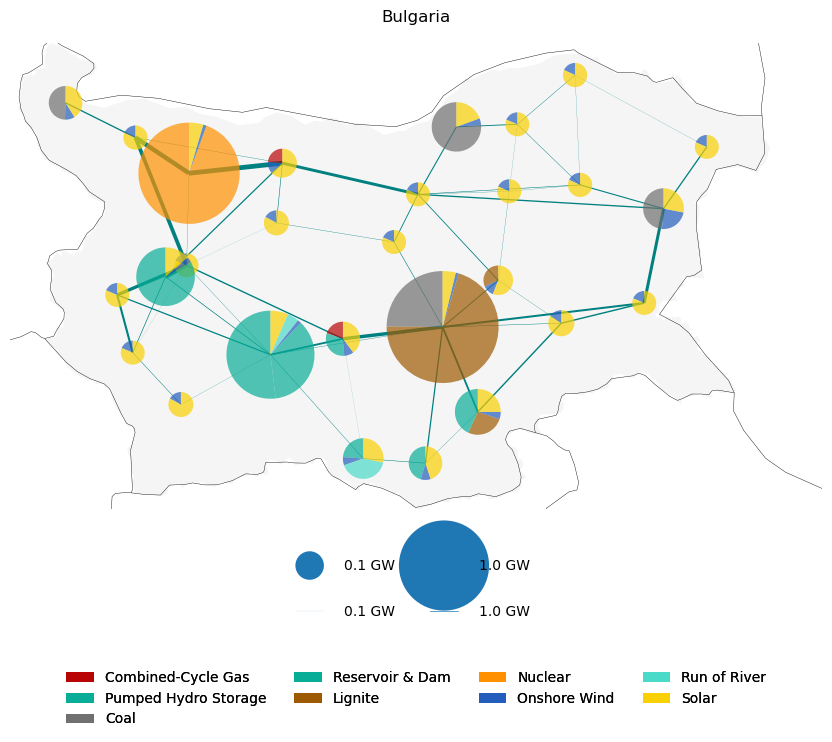

In [84]:
legend_kwargs = {
    "loc": "upper left",
    "frameon": False,
    "prop": {
        "family": "DejaVu Sans",
        "size": 12,
        "weight": "normal",
    },
}

# Scale settings
bus_scale = 1.5e4 
line_scale = 2e3

# Legend settings
bus_sizes = [100, 1000]  # in MW
line_sizes = [100,1000]  # in MW

#n.carriers.drop("Load", inplace=True)

fig, ax = plt.subplots(figsize=(16, 8), subplot_kw={"projection": ccrs.EqualEarth()})
gen = n.generators[(n.generators.carrier != "H2 export") & (n.generators.carrier != "load") & (n.generators.carrier != "export") & (n.generators.carrier != "load shedding")].groupby(["bus", "carrier"]).p_nom.sum()
converter = (
    n.links[
        (n.links.p_nom > 0)
        & n.links.bus1.str.contains("AC", na=False)
    ]
    .assign(p_nom_electric=lambda df: df.p_nom * df.efficiency)
    .groupby(["bus1", "carrier"])
    .p_nom_electric.sum()
)

# Rename bus1 to bus so all MultiIndex levels match
converter.index = converter.index.set_names(["bus", "carrier"])

sto = n.storage_units.groupby(["bus", "carrier"]).p_nom.sum()

# Capacities by bus and carrier for plotting
buses = (
    pd.concat([gen, converter, sto])
    .groupby(level=["bus", "carrier"])
    .sum()
)

buses = buses[buses > 0]

with plt.rc_context({"patch.linewidth": 0.}):
    n.plot(
        bus_sizes=buses / bus_scale,
        bus_alpha=0.7,
        line_widths=n.lines.s_nom_opt / line_scale,
        link_widths=n.links[n.links.carrier != "export"].p_nom_opt / line_scale,
        line_colors="teal",
        ax=ax,
        margin=0.2,
        color_geomap=None,
    )
regions_onshore.plot(
    ax=ax,
    facecolor="whitesmoke",
    edgecolor="white",
    aspect="equal",
    transform=ccrs.PlateCarree(),
    linewidth=0,
)
ax.set_extent(regions_onshore.total_bounds[[0, 2, 1, 3]])
legend_kwargs = {"loc": "upper left", "frameon": False}
legend_circles_dict = {"bbox_to_anchor": (1, 0.6), "labelspacing": 2, **legend_kwargs}

# Total installed capacity by carrier
carrier_cap = buses.groupby(level="carrier").sum()

# Keep only carriers with positive plotted capacity
used_carriers = carrier_cap[carrier_cap > 0].index

add_legend_circles(
    ax,
    [s / bus_scale for s in bus_sizes],
    [f"{s / 1000} GW" for s in bus_sizes],
    legend_kw={
        "loc": "upper center",
        "bbox_to_anchor": (0.5, -0.08),
        "frameon": False,
        "ncol": 2,
        "columnspacing": 3.0,   # Abstand zwischen den beiden Einträgen
        "handletextpad": 1.0,   # Abstand Symbol ↔ Text
    },
)
leg_lines  = add_legend_lines(
    ax,
    [s / line_scale for s in line_sizes],
    [f"{s / 1000} GW" for s in line_sizes],
    legend_kw={
        "loc": "upper center",
        "bbox_to_anchor": (0.5, -0.18),
        "frameon": False,
        "ncol": 2,
        "columnspacing": 3.0,   # Abstand zwischen den beiden Einträgen
        "handletextpad": 1.0,   # Abstand Symbol ↔ Text
        #"handlelength": 1,   # Standard ~2.0
    },
)

# nur die beiden Striche nach links verschieben
leg = ax.get_legend() if leg_lines is None else leg_lines

for h in leg.legend_handles:
    h.set_xdata(np.array(h.get_xdata()) - 5)  # größerer Wert = weiter links

n.carriers.loc["coal", "nice_name"] = "Coal"
n.carriers.loc["lignite", "nice_name"] = "Lignite"

add_legend_patches(
    ax,
    n.carriers.loc[used_carriers, "color"],
    n.carriers.loc[used_carriers, "nice_name"],
    legend_kw={
        "loc": "upper center",
        "bbox_to_anchor": (0.5, -0.32),
        "frameon": False,
        "ncol": 4,
    },
)

ax.set_title(
    "Bulgaria",
    fontfamily="DejaVu Sans",
    fontsize=12,
    fontweight="normal",
    pad=15,
    x=0.5
)

fig.tight_layout()

### Analyse the current generation capacity of the energy system - pie chart view

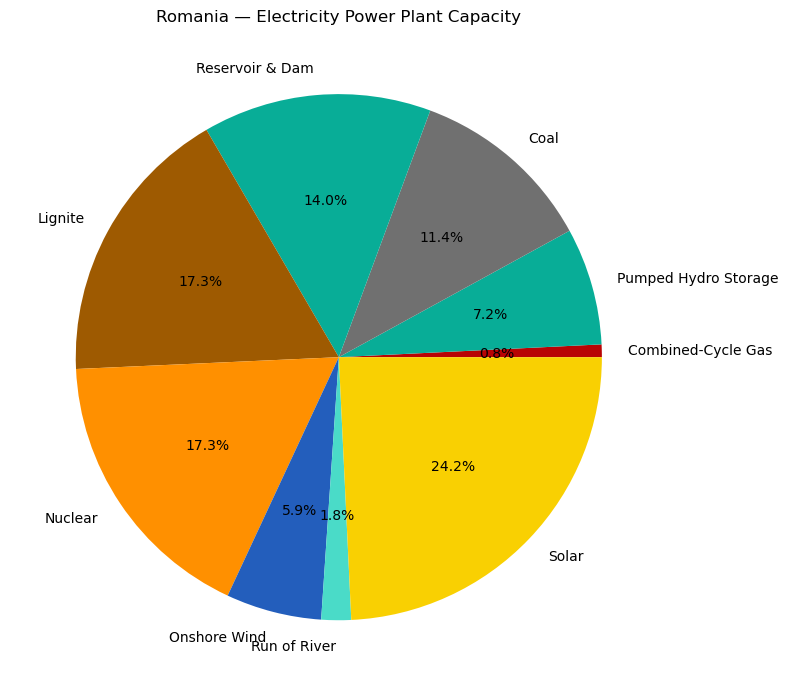

In [85]:
# Capacity by carrier from the previously calculated data
capacity_by_carrier = (
    buses.groupby(level="carrier")
    .sum()
)

capacity_by_carrier = capacity_by_carrier[
    capacity_by_carrier > 0
]

# Remove technologies contributing less than 0.05 %
shares = capacity_by_carrier / capacity_by_carrier.sum()
capacity_by_carrier = capacity_by_carrier[
    shares >= 0.0005
]

labels = n.carriers.loc[
    capacity_by_carrier.index,
    "nice_name"
].copy()

labels.loc["coal"] = "Coal"
labels.loc["lignite"] = "Lignite"

colors = n.carriers.loc[
    capacity_by_carrier.index,
    "color"
]

ax.pie(
    capacity_by_carrier.values,
    labels=labels.values,
    colors=colors.values,
    autopct="%1.1f%%",
);

fig, ax = plt.subplots(figsize=(8, 8))

wedges, texts, autotexts = ax.pie(
    capacity_by_carrier.values,
    labels=labels.values,
    autopct="%1.1f%%",
    colors=colors.values,
)

ax.set_title(
    "Romania — Electricity Power Plant Capacity",
    fontfamily="DejaVu Sans",
    fontsize=12,
    fontweight="normal",
    pad=5,
)

plt.tight_layout()
plt.show()

### Analyse the current gernation capacity of the energy system - tabular view

In [86]:
capacity_by_carrier/1e3 # in GW

carrier
CCGT       0.09300
PHS        0.86400
coal       1.36400
hydro      1.68442
lignite    2.07800
nuclear    2.08000
onwind     0.70431
ror        0.21900
solar      2.90813
dtype: float64

### Common country analysis

INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_Co2L0.45-1h_1h_2030_0.07_AB_0export.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_Co2L0.45-1h_1h_2030_0.07_AB_0export.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
/home/alex-charly/anaconda3/envs/pypsa-earth-HySEE-BG/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/alex-charly/anaconda3/envs/pypsa-earth-HySEE-BG/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


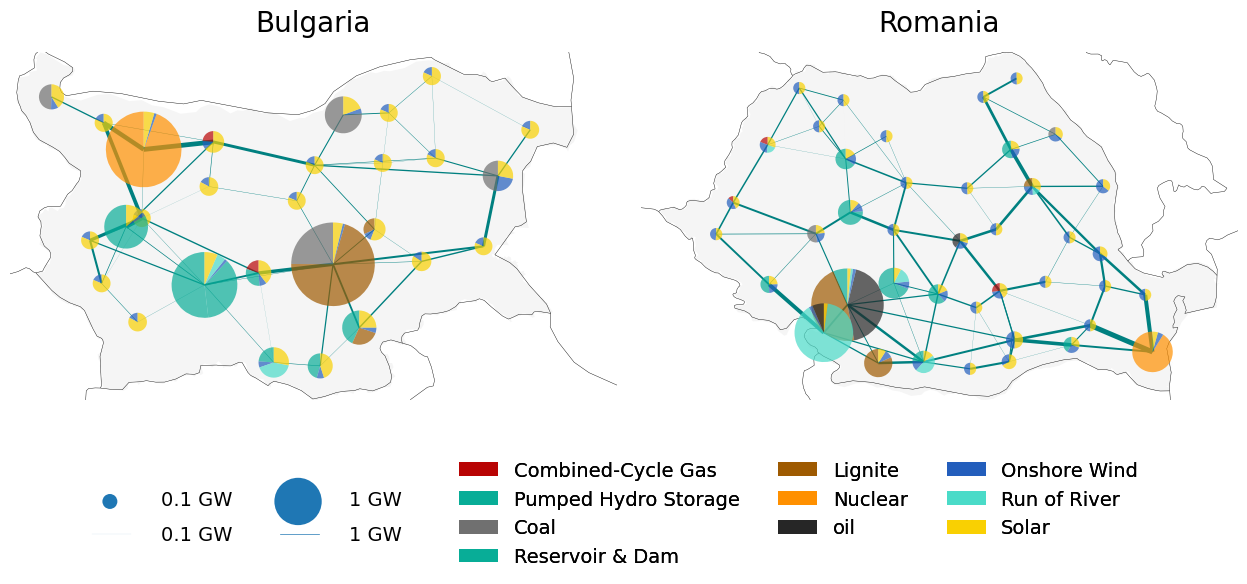

In [88]:
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import pypsa
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

from pypsa.plot import (
    add_legend_circles,
    add_legend_lines,
    add_legend_patches,
)


# Paths
results_path_BG = (
    "/mnt/e/HySEE/Bulgaria/pypsa-earth/results/1h-sec/postnetworks/"
    "elec_s_10_ec_lcopt_Co2L0.45-1h_1h_2030_0.07_AB_0export.nc"
)
regions_onshore_path_BG = (
    "/mnt/e/HySEE/Bulgaria/pypsa-earth/resources/1h-sec/"
    "shapes/country_shapes.geojson"
)

results_path_RO = (
    "/mnt/e/HySEE/Romania/pypsa-earth/results/1h-sec/postnetworks/"
    "elec_s_10_ec_lcopt_Co2L0.45-1h_1h_2030_0.07_AB_0export.nc"
)
regions_onshore_path_RO = (
    "/mnt/e/HySEE/Romania/pypsa-earth/resources/1h-sec/"
    "shapes/country_shapes.geojson"
)


# Load networks and shapes
warnings.simplefilter(action="ignore", category=FutureWarning)

n_BG = pypsa.Network(results_path_BG)
regions_onshore_BG = gpd.read_file(regions_onshore_path_BG)

n_RO = pypsa.Network(results_path_RO)
regions_onshore_RO = gpd.read_file(regions_onshore_path_RO)

warnings.simplefilter(action="default", category=FutureWarning)


# Scale settings
bus_scale = 1.5e4
line_scale = 2e3

bus_sizes = [100, 1000]       # MW
line_sizes = [100, 1000]      # MW


def get_electric_capacity_by_bus(n):
    """Return electricity-generation capacity by bus and carrier."""

    # Generators directly connected to electricity buses
    gen = (
        n.generators[
            ~n.generators.carrier.isin(
                [
                    "H2 export",
                    "load",
                    "export",
                    "load shedding",
                ]
            )
        ]
        .groupby(["bus", "carrier"])
        .p_nom.sum()
    )

    # Converter links producing electricity at bus1
    converter = (
        n.links[
            (n.links.p_nom > 0)
            & n.links.bus1.str.contains("AC", na=False)
            & ~n.links.carrier.isin(
                [
                    "export",
                    "H2 export",
                ]
            )
        ]
        .assign(
            p_nom_electric=lambda df: (
                df["p_nom"] * df["efficiency"]
            )
        )
        .groupby(["bus1", "carrier"])
        .p_nom_electric.sum()
    )

    # Rename bus1 index level so it matches generators and storage units
    converter.index = converter.index.set_names(
        ["bus", "carrier"]
    )

    # Storage units connected to electricity buses
    sto = (
        n.storage_units
        .groupby(["bus", "carrier"])
        .p_nom.sum()
    )

    # Combine capacities and merge duplicate bus-carrier combinations
    buses = (
        pd.concat([gen, converter, sto])
        .groupby(level=["bus", "carrier"])
        .sum()
    )

    return buses[buses > 0]


# Calculate plotted capacities once for each country
buses_BG = get_electric_capacity_by_bus(n_BG)
buses_RO = get_electric_capacity_by_bus(n_RO)


# Figure
fig, (ax_BG, ax_RO) = plt.subplots(
    1,
    2,
    figsize=(16, 6),
    subplot_kw={"projection": ccrs.EqualEarth()},
)

plot_data = [
    (ax_BG, n_BG, regions_onshore_BG, buses_BG, "Bulgaria"),
    (ax_RO, n_RO, regions_onshore_RO, buses_RO, "Romania"),
]


for ax, n, regions_onshore, buses, title in plot_data:

    # Plot country background first
    regions_onshore.plot(
        ax=ax,
        facecolor="whitesmoke",
        edgecolor="white",
        aspect="equal",
        transform=ccrs.PlateCarree(),
        linewidth=0,
        zorder=0,
    )

    # Plot electricity network and installed capacities
    with plt.rc_context({"patch.linewidth": 0.0}):
        n.plot(
            bus_sizes=buses / bus_scale,
            bus_alpha=0.7,
            line_widths=n.lines.s_nom_opt / line_scale,
            link_widths=(
                n.links.loc[
                    n.links.carrier != "export",
                    "p_nom_opt",
                ]
                / line_scale
            ),
            line_colors="teal",
            ax=ax,
            margin=0.2,
            color_geomap=None,
        )

    ax.set_extent(
        regions_onshore.total_bounds[[0, 2, 1, 3]]
    )

    ax.set_title(
        title,
        fontfamily="DejaVu Sans",
        fontsize=20,
        fontweight="normal",
        pad=15,
    )


# Common carrier legend based directly on plotted capacities
carrier_cap_BG = buses_BG.groupby(level="carrier").sum()
carrier_cap_RO = buses_RO.groupby(level="carrier").sum()

carrier_cap = (
    pd.concat([carrier_cap_BG, carrier_cap_RO])
    .groupby(level=0)
    .sum()
)

carrier_cap = carrier_cap.drop(
    [
        "load",
        "load shedding",
        "export",
        "H2 export",
    ],
    errors="ignore",
)

used_carriers = carrier_cap[
    carrier_cap > 0
].index


# Legends below both maps
add_legend_circles(
    ax_BG,
    [s / bus_scale for s in bus_sizes],
    [f"{s / 1000:g} GW" for s in bus_sizes],
    legend_kw={
        "loc": "upper center",
        "bbox_to_anchor": (0.4, -0.21),
        "frameon": False,
        "ncol": 2,
        "columnspacing": 3.0,
        "handletextpad": 1.0,
        "prop": {
            "family": "DejaVu Sans",
            "size": 14,
            "weight": "normal",
        },
    },
)

leg_lines = add_legend_lines(
    ax_BG,
    [s / line_scale for s in line_sizes],
    [f"{s / 1000:g} GW" for s in line_sizes],
    legend_kw={
        "loc": "upper center",
        "bbox_to_anchor": (0.4, -0.31),
        "frameon": False,
        "ncol": 2,
        "columnspacing": 3.0,
        "handletextpad": 1.0,
        "prop": {
            "family": "DejaVu Sans",
            "size": 14,
            "weight": "normal",
        },
    },
)

leg = ax_BG.get_legend() if leg_lines is None else leg_lines

for handle in leg.legend_handles:
    if hasattr(handle, "get_xdata"):
        handle.set_xdata(
            np.array(handle.get_xdata()) - 8
        )


# Carrier colors and names from both networks
carrier_colors = (
    n_BG.carriers
    .reindex(used_carriers)["color"]
    .fillna(
        n_RO.carriers.reindex(used_carriers)["color"]
    )
)

carrier_names = (
    n_BG.carriers
    .reindex(used_carriers)["nice_name"]
    .fillna(
        n_RO.carriers.reindex(used_carriers)["nice_name"]
    )
)

# Optional custom labels
carrier_names = carrier_names.copy()

if "coal" in carrier_names.index:
    carrier_names.loc["coal"] = "Coal"

if "lignite" in carrier_names.index:
    carrier_names.loc["lignite"] = "Lignite"


add_legend_patches(
    ax_BG,
    carrier_colors,
    carrier_names,
    legend_kw={
        "loc": "upper center",
        "bbox_to_anchor": (1.3, -0.125),
        "frameon": False,
        "ncol": 3,
        "prop": {
            "family": "DejaVu Sans",
            "size": 14,
            "weight": "normal",
        },
    },
)


fig.subplots_adjust(
    wspace=0.02,
    bottom=0.30,
)

plt.show()